# Week 2 Day 2 — Patient-Level Sepsis Risk Scoring

## ICU Early Warning Prediction System

In Week 2 Day 1, SHAP explainability was added to understand why the Gradient Boosting + SMOTE model predicts sepsis risk.

Today, the objective is to transform raw model probabilities into clinically understandable patient-level risk scores.

Instead of only predicting:

- 0 = No Sepsis
- 1 = Sepsis

we will generate:

- predicted sepsis probability
- risk percentage
- risk category
- clinical alert level

This makes the model easier to interpret in a real ICU early warning system.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures" / "day9"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Results path:", RESULTS_DIR)
print("Figures path:", FIGURES_DIR)
print("Figure directory exists:", FIGURES_DIR.exists())

Project root: c:\Users\User\OneDrive\Desktop\icu-early-warning-system
Data path: c:\Users\User\OneDrive\Desktop\icu-early-warning-system\data\processed
Results path: c:\Users\User\OneDrive\Desktop\icu-early-warning-system\results
Figures path: c:\Users\User\OneDrive\Desktop\icu-early-warning-system\figures\day9
Figure directory exists: True


In [4]:
data_file = DATA_PATH / "day2_patient_level_features.csv"

df = pd.read_csv(data_file)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100, 18)


,Patient_ID,HR_mean,HR_max,HR_min,O2Sat_mean,O2Sat_min,Temp_mean,Temp_max,SBP_mean,SBP_min,MAP_mean,MAP_min,Resp_mean,Resp_max,Age_first,Gender_first,ICULOS_max,SepsisLabel_max
0,p000001,101.907407,117.0,76.0,91.453704,85.0,36.735185,37.44,127.870370,78.0,88.321111,44.00,24.555556,32.0,83.14,0,54,0
1,p000002,62.173913,94.0,54.0,97.043478,94.0,36.206087,37.00,129.043478,114.0,67.239130,50.50,14.630435,27.0,75.91,0,23,0
2,p000003,79.968750,93.0,68.0,95.375000,91.0,37.465000,38.61,139.760417,121.0,81.149167,62.67,25.302083,40.0,45.82,0,48,0
3,p000004,102.172414,113.0,89.0,98.189655,95.5,36.463103,37.00,113.017241,90.0,67.063103,34.00,18.758621,26.0,65.71,0,29,0
4,p000005,76.604167,88.0,61.0,97.677083,96.0,37.072292,37.33,135.072917,114.0,90.364583,73.00,15.447917,21.0,28.09,1,49,0


In [5]:
target_col = "SepsisLabel_max"

X = df.drop(columns=["Patient_ID", target_col])
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (100, 16)
Target shape: (100,)


In [6]:
X_train, X_test, y_train, y_test, patient_id_train, patient_id_test = train_test_split(
    X,
    y,
    df["Patient_ID"],
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (75, 16)
Testing shape: (25, 16)


In [7]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
SepsisLabel_max
0    64
1    11
Name: count, dtype: int64

After SMOTE:
SepsisLabel_max
1    64
0    64
Name: count, dtype: int64


In [8]:
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

print("Gradient Boosting + SMOTE model trained successfully.")

Gradient Boosting + SMOTE model trained successfully.


In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88        22
           1       0.33      0.67      0.44         3

    accuracy                           0.80        25
   macro avg       0.64      0.74      0.66        25
weighted avg       0.87      0.80      0.83        25

ROC-AUC: 0.758


## Patient-Level Risk Score Design

The model outputs a probability between 0 and 1.

This probability is converted into a percentage risk score:

\[
Risk\ Score = P(Sepsis) \times 100
\]

The risk score is then mapped into clinical categories:

| Risk Score | Risk Category | Clinical Meaning |
|---|---|---|
| 0–25% | Low Risk | Patient currently appears stable |
| 25–50% | Moderate Risk | Patient should be monitored |
| 50–75% | High Risk | Patient may need clinical attention |
| 75–100% | Critical Risk | Patient should be urgently reviewed |

In [12]:
def categorize_risk(probability):
    risk_score = probability * 100

    if risk_score < 25:
        return "Low Risk"
    elif risk_score < 50:
        return "Moderate Risk"
    elif risk_score < 75:
        return "High Risk"
    else:
        return "Critical Risk"

In [13]:
def assign_alert_level(risk_category):
    if risk_category == "Low Risk":
        return "Routine Monitoring"
    elif risk_category == "Moderate Risk":
        return "Increased Monitoring"
    elif risk_category == "High Risk":
        return "Clinical Review Recommended"
    else:
        return "Urgent Clinical Review"

In [15]:
risk_results = pd.DataFrame({
    "Patient_ID": patient_id_test.values,
    "True_Sepsis_Label": y_test.values,
    "Predicted_Sepsis_Label": y_pred,
    "Sepsis_Probability": y_prob,
})

risk_results["Risk_Score_Percent"] = risk_results["Sepsis_Probability"] * 100
risk_results["Risk_Category"] = risk_results["Sepsis_Probability"].apply(categorize_risk)
risk_results["Clinical_Alert_Level"] = risk_results["Risk_Category"].apply(assign_alert_level)

risk_results = risk_results.sort_values(
    by="Risk_Score_Percent",
    ascending=False
)

risk_results.head(10)

,Patient_ID,True_Sepsis_Label,Predicted_Sepsis_Label,Sepsis_Probability,Risk_Score_Percent,Risk_Category,Clinical_Alert_Level
12,p000066,0,1,0.981967,98.196688,Critical Risk,Urgent Clinical Review
1,p000089,0,1,0.960523,96.052320,Critical Risk,Urgent Clinical Review
15,p000060,0,1,0.920321,92.032090,Critical Risk,Urgent Clinical Review
5,p000026,0,1,0.878321,87.832051,Critical Risk,Urgent Clinical Review
8,p000078,1,1,0.788835,78.883488,Critical Risk,Urgent Clinical Review
17,p000064,1,1,0.761729,76.172887,Critical Risk,Urgent Clinical Review
6,p000040,0,0,0.466792,46.679157,Moderate Risk,Increased Monitoring
23,p000027,0,0,0.335861,33.586112,Moderate Risk,Increased Monitoring
14,p000065,0,0,0.223953,22.395290,Low Risk,Routine Monitoring
24,p000086,0,0,0.131796,13.179550,Low Risk,Routine Monitoring


In [16]:
risk_results.to_csv(
    RESULTS_DIR / "day9_patient_level_risk_scores.csv",
    index=False
)

print("Patient-level risk scores saved successfully.")

Patient-level risk scores saved successfully.


In [17]:
risk_distribution = risk_results["Risk_Category"].value_counts().reset_index()
risk_distribution.columns = ["Risk_Category", "Number_of_Patients"]

risk_distribution

,Risk_Category,Number_of_Patients
0,Low Risk,17
1,Critical Risk,6
2,Moderate Risk,2


In [18]:
risk_distribution.to_csv(
    RESULTS_DIR / "day9_risk_category_distribution.csv",
    index=False
)

print("Risk category distribution saved successfully.")

Risk category distribution saved successfully.


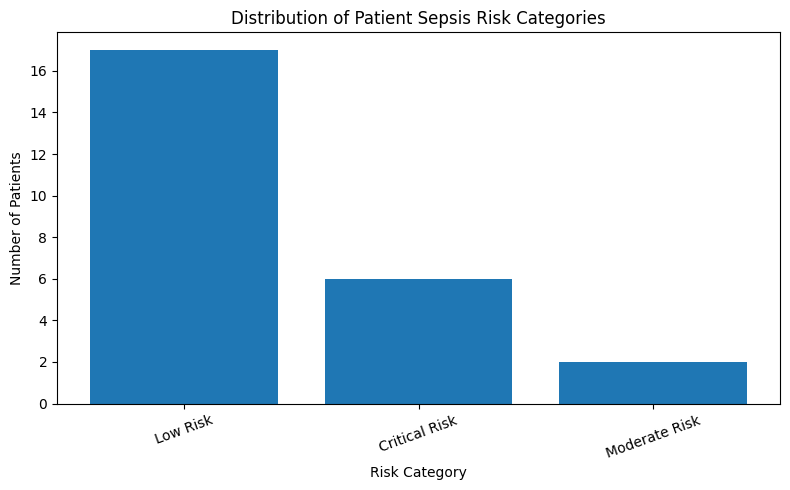

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_distribution["Risk_Category"],
    risk_distribution["Number_of_Patients"]
)

plt.title("Distribution of Patient Sepsis Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "risk_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
high_risk_patients = risk_results[
    risk_results["Risk_Category"].isin(["High Risk", "Critical Risk"])
]

high_risk_patients.head(30)

,Patient_ID,True_Sepsis_Label,Predicted_Sepsis_Label,Sepsis_Probability,Risk_Score_Percent,Risk_Category,Clinical_Alert_Level
12,p000066,0,1,0.981967,98.196688,Critical Risk,Urgent Clinical Review
1,p000089,0,1,0.960523,96.052320,Critical Risk,Urgent Clinical Review
15,p000060,0,1,0.920321,92.032090,Critical Risk,Urgent Clinical Review
5,p000026,0,1,0.878321,87.832051,Critical Risk,Urgent Clinical Review
8,p000078,1,1,0.788835,78.883488,Critical Risk,Urgent Clinical Review
17,p000064,1,1,0.761729,76.172887,Critical Risk,Urgent Clinical Review


In [23]:
high_risk_patients.to_csv(
    RESULTS_DIR / "day9_high_risk_patients.csv",
    index=False
)

print("High-risk patient list saved successfully.")

High-risk patient list saved successfully.


## Clinical Interpretation

The patient-level risk scoring system transforms model predictions into a more useful clinical format.

Instead of giving only a binary output, the system now provides:

- a sepsis probability
- a percentage risk score
- a risk severity category
- a clinical alert level

This is an important step toward building an ICU early warning system because clinicians need interpretable risk levels, not only machine learning labels.

Patients classified as high risk or critical risk can be prioritized for closer monitoring or clinical review.

In [24]:
print("Week 2 Day 2 completed successfully.")
print("Generated outputs:")
print("- day9_patient_level_risk_scores.csv")
print("- day9_risk_category_distribution.csv")
print("- day9_high_risk_patients.csv")
print("- risk_category_distribution.png")

Week 2 Day 2 completed successfully.
Generated outputs:
- day9_patient_level_risk_scores.csv
- day9_risk_category_distribution.csv
- day9_high_risk_patients.csv
- risk_category_distribution.png
